Title: frequency_analysis.ipynb

Author: Quin Aicken Davies

Date: 24/11/2025

Description: Perform a frequency analysis on the given dataset

In [39]:
import numpy as np
import pandas as pd
from Pyriod import Pyriod
import lightkurve as lk

from astropy.io import fits
from astropy.wcs import WCS
from astropy.table import Table
from astropy.stats import sigma_clipped_stats, SigmaClip
from astropy.nddata import NDData
from astropy.modeling.fitting import LevMarLSQFitter

from astropy.timeseries import LombScargle
from scipy.signal import find_peaks

# from photutils.detection import DAOStarFinder
# from photutils.psf import extract_stars, EPSFStars, EPSFBuilder, EPSFModel, PSFPhotometry, SourceGrouper, IterativePSFPhotometry
# from photutils.background import MMMBackground, LocalBackground

# from tqdm import tqdm

# import warnings
# from astropy.utils.exceptions import AstropyUserWarning

# from astropy.wcs import FITSFixedWarning

# warnings.filterwarnings('ignore', category=FITSFixedWarning)

# warnings.filterwarnings("ignore", category=RuntimeWarning)
# warnings.filterwarnings('ignore', category=AstropyUserWarning,
#                         message='.*fit.*not have converged.*')
# warnings.filterwarnings('ignore', category=AstropyUserWarning,
#                         message='.*fitting region extends beyond the star cutout image.*')
# warnings.filterwarnings("ignore", category=AstropyUserWarning, message=".*data contains invalid values.*")
import glob
import os
import matplotlib.pyplot as plt
# %matplotlib widget
# %matplotlib notebook
%matplotlib inline


In [40]:
"""Import the data for lightcurve analysis"""
# dates = ['20251030']
# dates = ['20251119']
# dates = ['20251122']
# dates = ['20251123']
# dates = ['20251030','20251119','20251122','20251123']
dates = ['initial']
for i in range(len(dates)):
    #Read in the data from all dates and concatenate into one dataframe
    try:
        print('Running on Linux machine')
        if dates[i] == 'initial':
            data_temp = pd.read_csv(f'/home/users/qai11/Documents/summer 2025 Data/Summer_Project_2025/Measurements_initial.xls', delimiter = '\t')
        else:
            data_temp = pd.read_csv(f'/home/users/qai11/Documents/summer 2025 Data/Summer_Project_2025/Measurements_{dates[i]}.csv', delimiter = ',')
        # data_temp = pd.read_csv(f'/home/users/qai11/Documents/summer 2025 Data/Summer_Project_2025/Measurements_{dates[i]}.xls', delimiter = '\t')
    except:
        try:
            print('Running on Windows machine')
            data_temp = pd.read_csv(f'E:/Summer 2025 Data/zzpscdata/Reduced/Measurements_{dates[i]}.csv', delimiter = ',')
        except:
            print('Running on Mac')
            data_temp = pd.read_csv(f'/Users/quin/Summer data/Summer_Project/Measurements_{dates[i]}.csv', delimiter = ',')
            
    if i == 0:
        data = data_temp
    else:
        data = pd.concat([data, data_temp], ignore_index=True)
if 'initial' in dates:
    target_data= data[:92]
else:
    target_data = data

"""Extract the object for plotting"""
zz_Psc_flux = target_data['rel_flux_T1']
zz_Psc_time = target_data['JD_UTC']
zz_Psc_flux_err = target_data['rel_flux_err_T1']
"""Convert flux and flux_err to magnitudes"""
zz_Psc_mag = -2.5 * np.log10(zz_Psc_flux)
zz_Psc_mag_err = (2.5 / np.log(10)) * (zz_Psc_flux_err / zz_Psc_flux) #constant for mag error conversion in ln

#Extract data from comparison stars C2 and C3
zz_Psc_flux_C2 = target_data['rel_flux_C2']
zz_Psc_flux_C3 = target_data['rel_flux_C3']
zz_Psc_flux_err_C2 = target_data['rel_flux_err_C2']
zz_Psc_flux_err_C3 = target_data['rel_flux_err_C3']
"""Convert flux and flux_err to magnitudes for C2 and C3"""
zz_Psc_mag_C2 = -2.5 * np.log10(zz_Psc_flux_C2)
zz_Psc_mag_C3 = -2.5 * np.log10(zz_Psc_flux_C3)
zz_Psc_mag_err_C2 = (2.5 / np.log(10)) * (zz_Psc_flux_err_C2 / zz_Psc_flux_C2) #constant for mag
zz_Psc_mag_err_C3 = (2.5 / np.log(10)) * (zz_Psc_flux_err_C3 / zz_Psc_flux_C3) #constant for mag

"""Create lightcurve object using the fluxes and times"""
# create and clean arrays, downsample if very large before making LightCurve
time = np.asarray(zz_Psc_time, dtype=float)
flux = np.asarray(zz_Psc_flux, dtype=float)
mask = np.isfinite(time) & np.isfinite(flux)
time, flux = time[mask], flux[mask]


# limit points to avoid huge messages to the frontend
max_points = 20000
if len(time) > max_points:
    idx = np.linspace(0, len(time) - 1, max_points).astype(int)
    time, flux = time[idx], flux[idx]

"""Create LightCurve object"""
lc = lk.LightCurve(time=time, flux=flux, flux_err=np.asarray(zz_Psc_flux_err, dtype=float)[mask])
time_array = lc.time.value   # removes units
flux_array = lc.flux.value   # removes units

"""Create a second light curve obsect using magnitudes """
lc_mag = lk.LightCurve(time=time, flux=zz_Psc_mag, flux_err=zz_Psc_mag_err)
time_array_mag = lc_mag.time.value   # removes units
mag_array = lc_mag.flux.value        # removes units



# from Pyriod import Pyriod
# # Pass these to Pyriod
# pyriod = Pyriod(lc)
# # pyriod.Pyriod()

# pyriod.TimeSeries()      # Light curve
# pyriod.Periodogram()     # Periodogram
# pyriod.Signals()         # Fitted signals (after adding)

Running on Linux machine


0     0.119367
1     0.116828
2     0.114802
3     0.115779
4     0.115236
5     0.115350
6     0.115330
7     0.117502
8     0.116779
9     0.121919
10    0.134935
Name: rel_flux_T1, dtype: float64

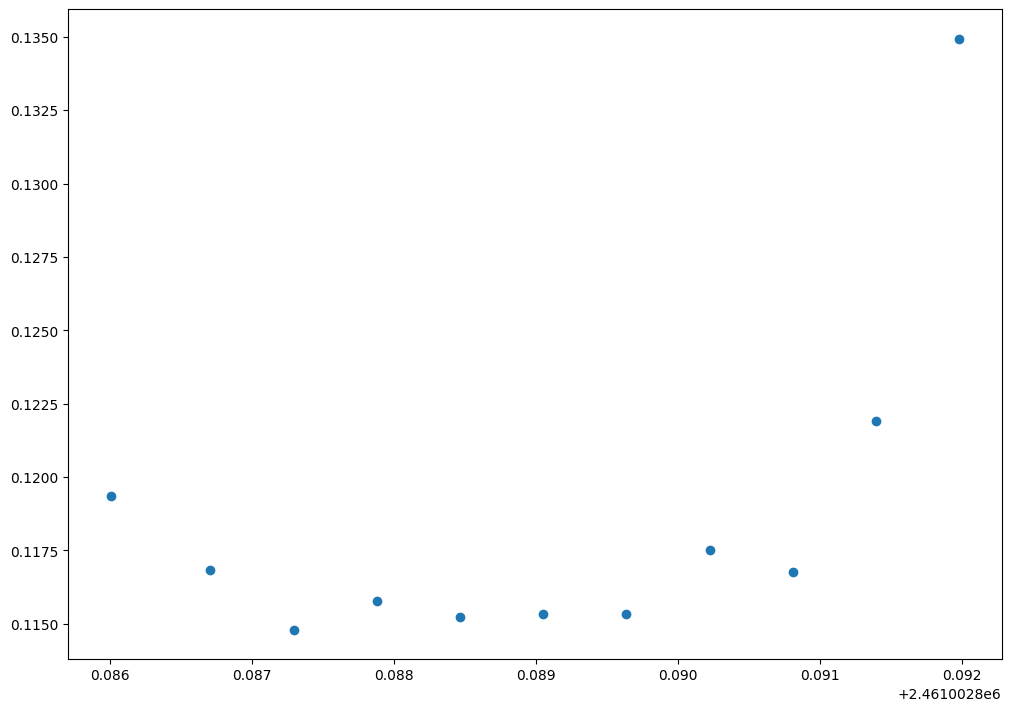

In [41]:
plt.figure(figsize=(10, 7), constrained_layout=True)
plt.scatter(time_array,zz_Psc_flux)
zz_Psc_flux

Flux periodogram peaks:
   rank    frequency   period     power  fap_baluev  fap_bootstrap       fap
0     1  1639.506742  0.00061  0.710269    0.245934            NaN  0.245934

Magnitude periodogram peaks:
   rank    frequency   period     power  fap_baluev  fap_bootstrap       fap
0     1  1639.506742  0.00061  0.715877    0.006517            NaN  0.006517


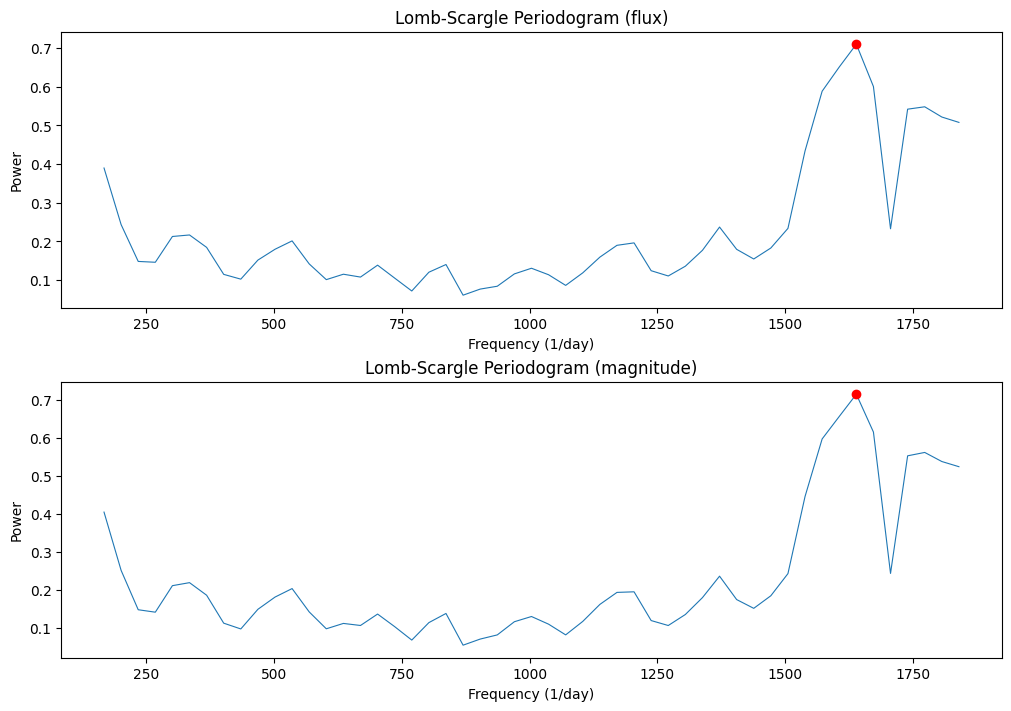

In [42]:
"""Use lombscargle instead of Pyriod and repeat analysis for magnitude lightcurve"""

def analyze_lomb(t, y, label='flux', n_peaks=10, n_bootstrap=500,
                 nyquist_factor=2, min_freq_factor=1.0, peak_distance=5):
    ls = LombScargle(t, y, normalization='standard')
    baseline = t.max() - t.min()
    frequency, power = ls.autopower(nyquist_factor=nyquist_factor,
                                    minimum_frequency=min_freq_factor / baseline)

    # peak detection
    thresh = np.mean(power) + 2 * np.std(power)
    peaks, props = find_peaks(power, height=thresh, distance=peak_distance)
    if len(peaks) == 0:
        print(f"No peaks found for {label} (threshold {thresh:.3g})")
        return pd.DataFrame([]), frequency, power, peaks, props

    top_idxs = np.argsort(power[peaks])[::-1][:n_peaks]

    # lazy bootstrap (compute only if analytic FAP unavailable)
    bootstrap_max_powers = None

    results = []
    for rank, pidx in enumerate(top_idxs, start=1):
        idx = peaks[pidx]
        freq_peak = frequency[idx]
        period_peak = 1.0 / freq_peak
        pwr = power[idx]

        fap_baluev = None
        try:
            fap_baluev = ls.false_alarm_probability(pwr, method='baluev',
                                                    maximum_frequency=frequency.max())
        except Exception:
            fap_baluev = None

        fap_boot = None
        if fap_baluev is None or (isinstance(fap_baluev, float) and np.isnan(fap_baluev)):
            if bootstrap_max_powers is None:
                bootstrap_max_powers = np.empty(n_bootstrap)
                for i in range(n_bootstrap):
                    y_sh = np.random.permutation(y)
                    ls_sh = LombScargle(t, y_sh, normalization='standard')
                    p_sh = ls_sh.power(frequency)
                    bootstrap_max_powers[i] = p_sh.max()
            fap_boot = (np.sum(bootstrap_max_powers >= pwr) + 1) / (n_bootstrap + 1)

        fap_report = fap_baluev if (fap_baluev is not None and not np.isnan(fap_baluev)) else fap_boot

        results.append({
            'rank': rank,
            'frequency': float(freq_peak),
            'period': float(period_peak),
            'power': float(pwr),
            'fap_baluev': float(fap_baluev) if (fap_baluev is not None and not np.isnan(fap_baluev)) else np.nan,
            'fap_bootstrap': float(fap_boot) if fap_boot is not None else np.nan,
            'fap': float(fap_report) if fap_report is not None else np.nan
        })

    df = pd.DataFrame(results)
    return df, frequency, power, peaks, props, baseline

# run for flux (existing)
t = time_array - time_array.min()  # zero-point time
# t = time_array
y = flux_array
df_peaks, frequency, power, peaks, props, baseline = analyze_lomb(t, y, label='flux',
                                                        n_peaks=10, n_bootstrap=500)

print("Flux periodogram peaks:")
print(df_peaks)

# run same analysis for magnitudes
t_mag = time_array
y_mag = mag_array
df_peaks_mag, frequency_mag, power_mag, peaks_mag, props_mag, baseline_mag = analyze_lomb(
    t_mag, y_mag, label='magnitude', n_peaks=10, n_bootstrap=500)

print("\nMagnitude periodogram peaks:")
print(df_peaks_mag)

# quick comparative plotting: two stacked periodograms with detected peaks
fig, ax = plt.subplots(2, 1, figsize=(10, 7), constrained_layout=True)

ax[0].plot(frequency, power, lw=0.8)
if len(df_peaks):
    ax[0].scatter(df_peaks['frequency'], df_peaks['power'], color='r', zorder=5)
ax[0].set_xlabel('Frequency (1/day)')
ax[0].set_ylabel('Power')
ax[0].set_title('Lomb-Scargle Periodogram (flux)')

ax[1].plot(frequency_mag, power_mag, lw=0.8)
if len(df_peaks_mag):
    ax[1].scatter(df_peaks_mag['frequency'], df_peaks_mag['power'], color='r', zorder=5)
ax[1].set_xlabel('Frequency (1/day)')
ax[1].set_ylabel('Power')
ax[1].set_title('Lomb-Scargle Periodogram (magnitude)')

plt.savefig('periodograms_flux_and_mag.png', dpi=150)
plt.show()

# keep the per-analysis CSVs if desired
# df_peaks.to_csv('periodogram_peaks_flux.csv', index=False)
# df_peaks_mag.to_csv('periodogram_peaks_mag.csv', index=False)

In [43]:
"""Perform some prewhitening iterations, default 3"""
def prewhiten_lomb(dates, t, T1, T1_err, C2,C3,C2_err,C3_err, n_iter=3,  store_periodograms=False, save_data=False, magnitudes=False):
    #Inputs expected from previous cells

    # Iteration numbers
    n_iter = 7
    #Create a copy of the data to work on
    residual = T1.copy()
    found_freqs = []

    # store intermediate periodograms if wanted
    periodograms = []

    for it in range(n_iter):
        ls_res = LombScargle(t, residual, normalization='standard')
        freq_res, power_res = ls_res.autopower(nyquist_factor=2, minimum_frequency=1.0 / baseline)
        periodograms.append((freq_res.copy(), power_res.copy()))

        # choose highest peak frequency
        peak_idx = np.argmax(power_res)
        f_peak = float(freq_res[peak_idx])
        found_freqs.append(f_peak)

        # linear fit for cos and sin and constant: residual ~ a*cos(omega t) + b*sin(omega t) + c
        omega = 2.0 * np.pi * f_peak
        X = np.vstack([np.cos(omega * t), np.sin(omega * t), np.ones_like(t)]).T
        coeffs, *_ = np.linalg.lstsq(X, residual, rcond=None)
        a, b, c = coeffs
        comp_model = X.dot(coeffs)

        # subtract component
        residual = residual - comp_model

        print(f"iter {it+1}: f = {f_peak:.6f}  period = {1.0/f_peak:.6f} (1/d) amp = {np.hypot(a,b):.5g}  offset = {c:.5g}")

    # final combined fit using the found frequencies (fit all at once to original data)
    if len(found_freqs) == 0:
        raise RuntimeError("No frequencies found; reduce threshold or increase frequency resolution.")


    # Compute weights
    weights = 1.0 / T1_err**2  # inverse variance weighting

    # build design matrix with all components + constant
    cols = []
    for f in found_freqs:
        omega = 2.0 * np.pi * f
        cols.append(np.cos(omega * t))
        cols.append(np.sin(omega * t))
    cols.append(np.ones_like(t))
    X_all = np.vstack(cols).T
    coeffs_all, *_ = np.linalg.lstsq(X_all, T1, rcond=None)

    # Apply weights to design matrix and observations
    W = np.sqrt(np.array(weights))[:, None]  # shape (n, 1)
    X_weighted = X_all * W
    T1_weighted = T1 * W.ravel()

    # Solve weighted least squares
    coeffs_all, *_ = np.linalg.lstsq(X_weighted, T1_weighted, rcond=None)

    # unpack coefficients and build model
    model_total = X_all.dot(coeffs_all)
    residual_final = T1 - model_total

    # derive component amplitudes/phases/offset
    components = []
    for i, f in enumerate(found_freqs):
        a = coeffs_all[2*i]
        b = coeffs_all[2*i + 1]
        amp = np.hypot(a, b)
        phase = np.arctan2(b, a)            # phase so that component = amp * cos(omega t - phase)
        components.append({'frequency': float(f),
                        'period': float(1.0/f),
                        'a': float(a),
                        'b': float(b),
                        'amplitude': float(amp),
                        'phase_rad': float(phase)})

    # constant offset is last coeff
    offset = float(coeffs_all[-1])

    # save components
    df_comp = pd.DataFrame(components)
    df_comp['offset'] = offset
    print(df_comp)

    """plots: data vs model, residuals, periodograms before/after"""
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), constrained_layout=True)

    """Plots normilized fluxes against time"""
    # center fluxes on zero for easier comparison
    data_centered = T1 - np.nanmean(T1)
    c2_centered = np.asarray(C2, dtype=float) - np.nanmean(C2)
    c3_centered = np.asarray(C3, dtype=float) - np.nanmean(C3)

    # normalize/center the model to the same baseline as the data
    model_at_data = np.asarray(model_total, dtype=float)
    model_centered = model_at_data - np.nanmean(model_at_data)

    # Sort time and model together
    sort_idx = np.argsort(t)
    t_sorted = t[sort_idx]
    model_sorted = model_centered[sort_idx]

    """Plotting creating a dense time grid for smooth model plotting"""
    # Create a dense time grid for smooth plotting
    t_dense = np.linspace(t_sorted.min(), t_sorted.max(), 100)  

    # Build design matrix for dense grid
    cols_dense = []
    for f in found_freqs:
        omega = 2.0 * np.pi * f
        cols_dense.append(np.cos(omega * t_dense))
        cols_dense.append(np.sin(omega * t_dense))
    cols_dense.append(np.ones_like(t_dense))
    X_dense = np.vstack(cols_dense).T

    # Compute model on dense grid
    model_dense = X_dense.dot(coeffs_all)
    model_dense_centered = model_dense - np.nanmean(model_dense)

    # optional: scale model amplitude to match data std (uncomment if desired)
    # data_std = np.nanstd(data_centered)
    # model_std = np.nanstd(model_centered)
    # if model_std > 0:
    #     model_centered = model_centered * (data_std / model_std)

    axes[0].errorbar(t_sorted, data_centered, yerr=np.asarray(T1_err, dtype=float)[mask],
                    fmt='.', ms=4, label='data (zero-mean)')
    axes[0].errorbar(t_sorted, c2_centered, yerr=np.asarray(C2_err, dtype=float)[mask],
                    color='green', label='C2 (zero-mean)', fmt='.', ms=4)
    axes[0].errorbar(t_sorted, c3_centered, yerr=np.asarray(C3_err, dtype=float)[mask],
                    color='orange', label='C3 (zero-mean)', fmt='.', ms=4)

    # Smooth model line
    axes[0].plot(t_dense, model_dense_centered, '-', lw=1.5, color='orange', alpha=0.8, label='model (smooth)')
    axes[0].plot(t_sorted, model_sorted, '-', lw=1.0, alpha=0.6, label='model (at data times)')


    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('Rel_Flux')
    axes[0].legend()
    axes[0].set_title('Normilized Data and prewhitened model')
    # axes[0].set_xlim(left=0, right=0.2) 

    # subplot 2: data + model
    """Plots non normilized fluxes against time"""
    axes[1].errorbar(t_sorted, T1, yerr=np.asarray(T1_err, dtype=float)[mask], fmt='.', ms=4, label='data')
    axes[1].errorbar(t_sorted,C2, yerr=np.asarray(C2_err, dtype=float)[mask], color='green', label='C2', fmt='.', ms=4)
    axes[1].errorbar(t_sorted,C3, yerr=np.asarray(C3_err, dtype=float)[mask], color='orange', label='C3', fmt='.', ms=4)
    axes[1].plot(t_sorted, model_total, '-', lw=1.0, alpha=0.6, label='model (at data times)')
    # axes[1].plot(t_sorted, model_dense, '-', lw=1.5, color='orange', alpha=0.8, label='model (smooth)')
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('Rel_Flux')
    axes[1].legend()
    axes[1].set_title('Data and prewhitened model')


    # subplot 3: residuals
    axes[2].plot(t_sorted, residual_final, '.', ms=4)
    axes[2].set_xlabel('Time')
    axes[2].set_ylabel('Residual flux')
    axes[2].set_title('Final residuals')

    # subplot 4: periodograms (all iterations + final)
    N = len(periodograms)
    if N == 0:
        axes[3].text(0.5, 0.5, 'no periodograms recorded', ha='center')
    else:
        cmap = plt.cm.viridis
        colors = cmap(np.linspace(0, 1, N))
        for i, (f_i, p_i) in enumerate(periodograms):
            axes[3].plot(f_i, p_i, color=colors[i], alpha=0.6, lw=1.0, label=f'iter {i+1}')
        ls_final = LombScargle(t_sorted, residual_final, normalization='standard')
        freq_r, power_r = ls_final.autopower(nyquist_factor=2, minimum_frequency=1.0 / baseline)
        axes[3].plot(freq_r, power_r, color='C1', lw=2.0, alpha=0.95, label='residuals (final)') #make amplitude
        for ff in found_freqs:
            axes[3].axvline(ff, color='k', ls='--', lw=0.8, alpha=0.6)
        axes[3].set_xlabel('Frequency')
        axes[3].set_ylabel('Power')
        axes[3].legend(ncol=2, fontsize='small')
        axes[3].set_title('Periodograms: all iterations and final residual')

    if save_data == True:
        if magnitudes == False:
            output_file = '/home/users/qai11/Documents/summer 2025 Data/Summer_Project_2025/Reduction Code/Output_frequencies/'
            plt.savefig(output_file + f'{dates}_Flux_prewhitening_figure.png', dpi=150)
            
            # save final arrays
            final_array = pd.DataFrame({
                'time': t,
                'data': y,
                'model': model_total,
                'residual': residual_final
            })
            final_array.to_csv(output_file + f'{dates}_Flux_model_vs_time.csv', index=False)
            print("\nSaved model_vs_time.csv")
            
            # save lombscargle results
            df_comp.to_csv(output_file + f'{dates}_Flux_prewhitening_components.csv', index=False)
            print("\nSaved prewhitening_components.csv")
        else:
            output_file = '/home/users/qai11/Documents/summer 2025 Data/Summer_Project_2025/Reduction Code/Output_frequencies/'
            plt.savefig(output_file + f'{dates}_Mag_prewhitening_figure.png', dpi=150)
            
            # save final arrays
            final_array = pd.DataFrame({
                'time': t,
                'data': y,
                'model': model_total,
                'residual': residual_final
            })
            final_array.to_csv(output_file + f'{dates}_Mag_model_vs_time.csv', index=False)
            print("\nSaved model_vs_time.csv")
            
            # save lombscargle results
            df_comp.to_csv(output_file + f'{dates}_Mag_prewhitening_components.csv', index=False)
            print("\nSaved prewhitening_components.csv")

    # optional: print FAPs for final components using LombScargle on original data
    # ls_orig = LombScargle(t, y, normalization='standard')
    # fap_list = []
    # for comp in components:
    #     f = comp['frequency']
    #     # compute power at that frequency
    #     pwr = ls_orig.power(f)
    #     # analytic fap (baluev) try
    #     try:
    #         fap_b = ls_orig.false_alarm_probability(pwr, method='baluev', maximum_frequency=freq0.max())
    #     except Exception:
    #         fap_b = np.nan
    #     fap_list.append({'frequency': f, 'power': float(pwr), 'fap_baluev': float(fap_b)})
    # # df_fap = pd.DataFrame(fap_list)
    # # df_fap.to_csv('component_faps.csv', index=False)
    # print("Saved component_faps.csv")
    



iter 1: f = 1639.506742  period = 0.000610 (1/d) amp = 0.016339  offset = 0.13057
iter 2: f = 301.133891  period = 0.003321 (1/d) amp = 0.0030237  offset = 5.235e-05
iter 3: f = 468.430498  period = 0.002135 (1/d) amp = 0.0021779  offset = -6.6161e-05
iter 4: f = 1840.262670  period = 0.000543 (1/d) amp = 0.0019357  offset = 0.00037577
iter 5: f = 1070.698280  period = 0.000934 (1/d) amp = 0.00089787  offset = 3.7847e-05
iter 6: f = 1204.535566  period = 0.000830 (1/d) amp = 0.00025098  offset = -1.7615e-05
iter 7: f = 936.860995  period = 0.001067 (1/d) amp = 0.00013197  offset = -9.3719e-06
     frequency    period         a         b  amplitude  phase_rad    offset
0  1639.506742  0.000610  0.052026 -0.006112   0.052384  -0.116953  0.078718
1   301.133891  0.003321 -0.004606 -0.003596   0.005843  -2.478619  0.078718
2   468.430498  0.002135 -0.007890 -0.007827   0.011113  -2.360201  0.078718
3  1840.262670  0.000543  0.012124  0.008521   0.014819   0.612636  0.078718
4  1070.698280 

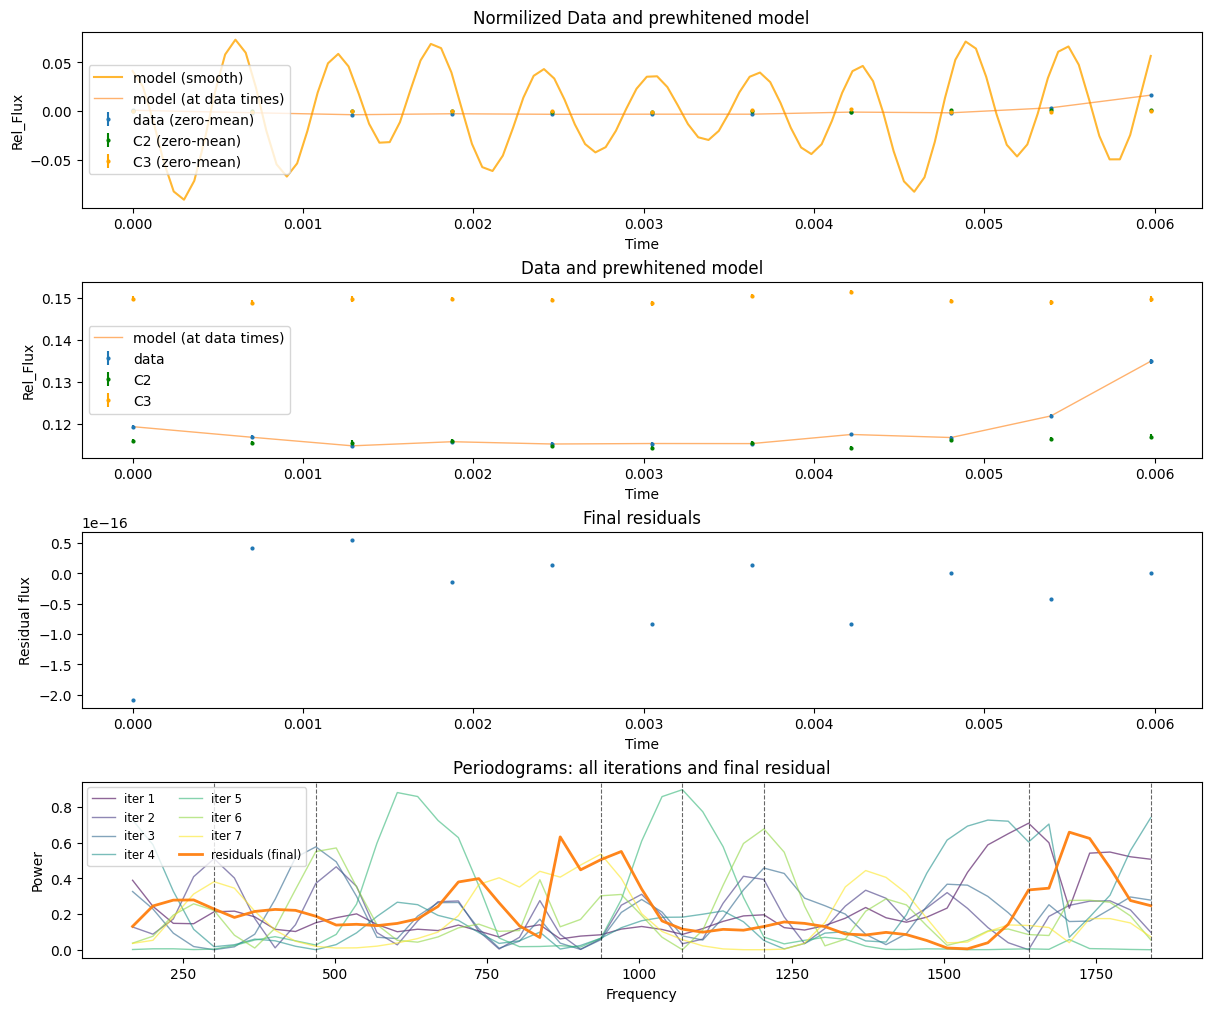

In [44]:
"""Run flux data through prewhitening"""
prewhiten_lomb(dates, t, flux_array, zz_Psc_flux_err, zz_Psc_flux_C2,zz_Psc_flux_C3,zz_Psc_flux_err_C2,zz_Psc_flux_err_C3, n_iter=7, 
               store_periodograms=True, save_data=True, magnitudes=False)

iter 1: f = 1639.506742  period = 0.000610 (1/d) amp = 0.14228  offset = 2.2119
iter 2: f = 301.133891  period = 0.003321 (1/d) amp = 0.026093  offset = -0.00045394
iter 3: f = 468.430498  period = 0.002135 (1/d) amp = 0.018806  offset = 0.00056448
iter 4: f = 1840.262670  period = 0.000543 (1/d) amp = 0.017219  offset = -0.0033531
iter 5: f = 1037.238959  period = 0.000964 (1/d) amp = 0.0074678  offset = 0.00012221
iter 6: f = 501.889819  period = 0.001992 (1/d) amp = 0.0024889  offset = -0.00012428
iter 7: f = 1371.832172  period = 0.000729 (1/d) amp = 0.0013232  offset = 4.7043e-05
     frequency    period         a         b  amplitude  phase_rad    offset
0  1639.506742  0.000610 -0.511042 -0.797491   0.947183  -2.140686  1.576834
1   301.133891  0.003321  0.005536  0.272607   0.272663   1.550490  1.576834
2   468.430498  0.002135 -0.109626  0.201904   0.229746   2.068219  1.576834
3  1840.262670  0.000543  0.110489  0.072077   0.131920   0.578023  1.576834
4  1037.238959  0.00096

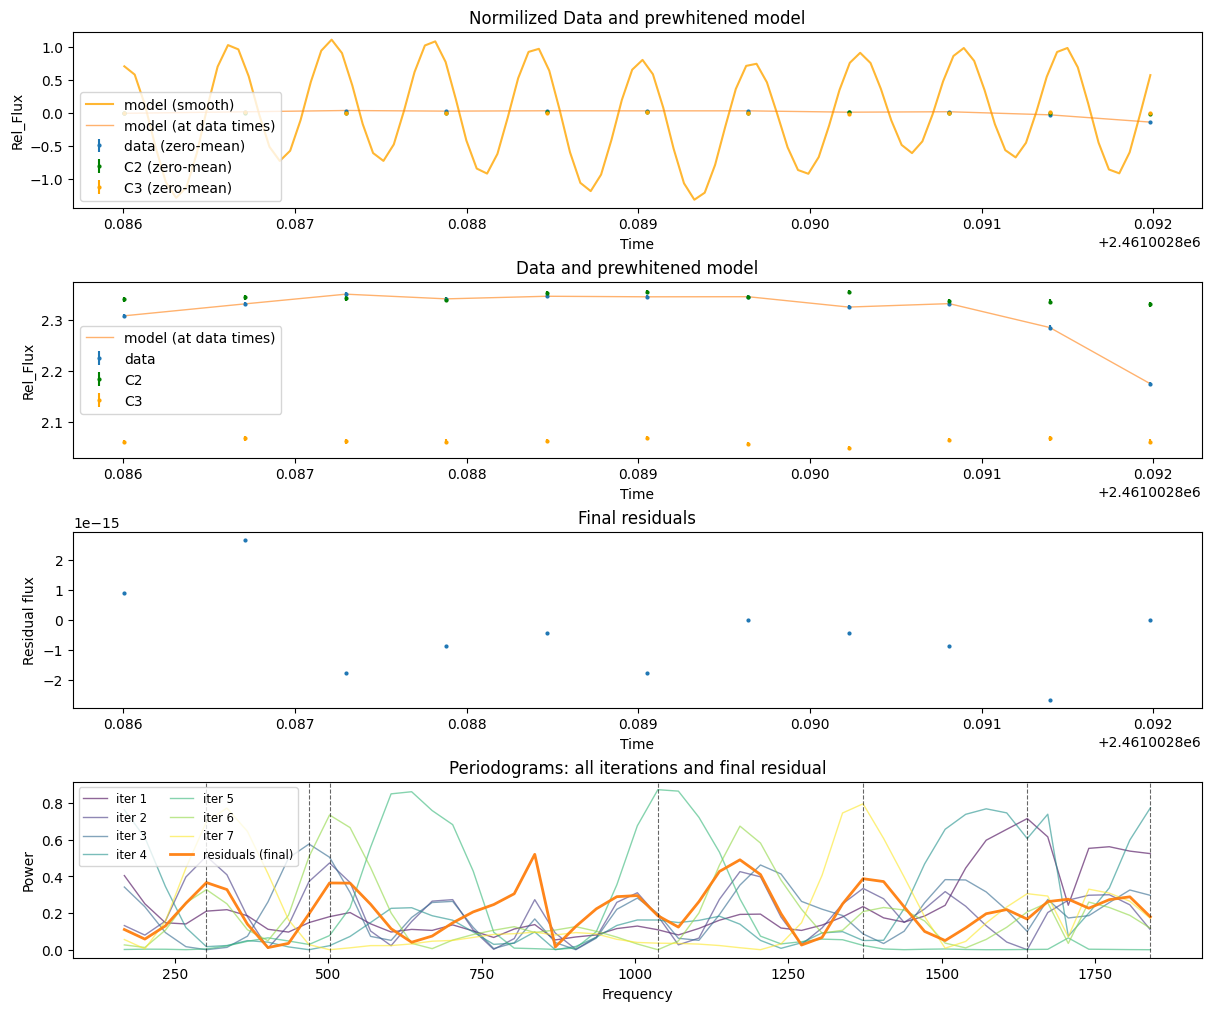

In [45]:
"""Run magnitude data through prewhitening"""
prewhiten_lomb(dates, t_mag, mag_array, zz_Psc_mag_err, zz_Psc_mag_C2,zz_Psc_mag_C3,zz_Psc_mag_err_C2,zz_Psc_mag_err_C3, n_iter=7, 
               store_periodograms=True, save_data=True, magnitudes=True)

In [46]:
"""OLD code that works but not currently using"""

# """Perform some prewhitening on the Mag dataiterations, default 3"""

# #Inputs expected from previous cells
# # Iteration numbers
# n_iter = 7
# #Create a copy of the data to work on
# residual = y_mag.copy()
# found_freqs = []

# # store intermediate periodograms if wanted
# periodograms = []

# for it in range(n_iter):
#     ls_res = LombScargle(t, residual, normalization='standard')
#     freq_res, power_res = ls_res.autopower(nyquist_factor=2, minimum_frequency=1.0 / baseline_mag)
#     periodograms.append((freq_res.copy(), power_res.copy()))

#     # choose highest peak frequency
#     peak_idx = np.argmax(power_res)
#     f_peak = float(freq_res[peak_idx])
#     found_freqs.append(f_peak)

#     # linear fit for cos and sin and constant: residual ~ a*cos(omega t) + b*sin(omega t) + c
#     omega = 2.0 * np.pi * f_peak
#     X = np.vstack([np.cos(omega * t), np.sin(omega * t), np.ones_like(t)]).T
#     coeffs, *_ = np.linalg.lstsq(X, residual, rcond=None)
#     a, b, c = coeffs
#     comp_model = X.dot(coeffs)

#     # subtract component
#     residual = residual - comp_model

#     print(f"iter {it+1}: f = {f_peak:.6f}  period = {1.0/f_peak:.6f} (1/d) amp = {np.hypot(a,b):.5g}  offset = {c:.5g}")

# # final combined fit using the found frequencies (fit all at once to original data)
# if len(found_freqs) == 0:
#     raise RuntimeError("No frequencies found; reduce threshold or increase frequency resolution.")

# # build design matrix with all components + constant
# cols = []
# for f in found_freqs:
#     omega = 2.0 * np.pi * f
#     cols.append(np.cos(omega * t))
#     cols.append(np.sin(omega * t))
# cols.append(np.ones_like(t))
# X_all = np.vstack(cols).T
# coeffs_all, *_ = np.linalg.lstsq(X_all, y_mag, rcond=None)

# # unpack coefficients and build model
# model_total = X_all.dot(coeffs_all)
# residual_final = y_mag - model_total

# # derive component amplitudes/phases/offset
# components = []
# for i, f in enumerate(found_freqs):
#     a = coeffs_all[2*i]
#     b = coeffs_all[2*i + 1]
#     amp = np.hypot(a, b)
#     phase = np.arctan2(b, a)            # phase so that component = amp * cos(omega t - phase)
#     components.append({'frequency': float(f),
#                        'period': float(1.0/f),
#                        'a': float(a),
#                        'b': float(b),
#                        'amplitude': float(amp),
#                        'phase_rad': float(phase)})

# # constant offset is last coeff
# offset = float(coeffs_all[-1])

# # save components
# df_comp = pd.DataFrame(components)
# df_comp['offset'] = offset
# # df_comp.to_csv('prewhitening_components.csv', index=False)
# # print("\nSaved prewhitening_components.csv")
# print(df_comp)

# """plots: data vs model, residuals, periodograms before/after"""
# fig, axes = plt.subplots(4, 1, figsize=(12, 10), constrained_layout=True)
# """Plots normilized mag against time"""
# axes[0].errorbar(t, y_mag - np.nanmean(y_mag), yerr=np.asarray(zz_Psc_mag_err, dtype=float)[mask],
#                  fmt='.', ms=4, label='data (zero-mean)')
# axes[0].errorbar(t, zz_Psc_mag_C2 - np.nanmean(zz_Psc_mag_C2), yerr=np.asarray(zz_Psc_mag_err_C2, dtype=float)[mask],
#                  color='green', label='C2 (zero-mean)', fmt='.', ms=4)
# axes[0].errorbar(t, zz_Psc_mag_C3 - np.nanmean(zz_Psc_mag_C3), yerr=np.asarray(zz_Psc_mag_err_C3, dtype=float)[mask],
#                  color='orange', label='C3 (zero-mean)', fmt='.', ms=4)
# axes[0].plot(t, model_total - np.nanmean(model_total), '-', lw=1.0, alpha=0.6, label='model (zero-mean)')
# axes[0].set_xlabel('Time')
# axes[0].set_ylabel('Magnitude')
# axes[0].legend()
# axes[0].set_title('Normilized Data and prewhitened model')
# """Plots non normilized mag against time"""
# # subplot 1: data + model
# axes[1].errorbar(t, y_mag, yerr=np.asarray(zz_Psc_mag_err, dtype=float)[mask], fmt='.', ms=4, label='data')
# axes[1].errorbar(t,zz_Psc_mag_C2, yerr=np.asarray(zz_Psc_mag_err_C2, dtype=float)[mask], color='green', label='C2', fmt='.', ms=4)
# axes[1].errorbar(t,zz_Psc_mag_C3, yerr=np.asarray(zz_Psc_mag_err_C3, dtype=float)[mask], color='orange', label='C3', fmt='.', ms=4)
# axes[1].plot(t, model_total, '-', lw=1.0, alpha=0.6, label='model (at data times)')
# axes[1].set_xlabel('Time')
# axes[1].set_ylabel('Magnitude')
# axes[1].legend()
# axes[1].set_title('Data and prewhitened model')

# # subplot 2: residuals
# axes[2].plot(t, residual_final, '.', ms=4)
# axes[2].set_xlabel('Time')
# axes[2].set_ylabel('Residual flux')
# axes[2].set_title('Final residuals')

# # subplot 3: periodograms (all iterations + final)
# N = len(periodograms)
# if N == 0:
#     axes[3].text(0.5, 0.5, 'no periodograms recorded', ha='center')
# else:
#     cmap = plt.cm.viridis
#     colors = cmap(np.linspace(0, 1, N))
#     for i, (f_i, p_i) in enumerate(periodograms):
#         axes[3].plot(f_i, p_i, color=colors[i], alpha=0.6, lw=1.0, label=f'iter {i+1}')
#     ls_final = LombScargle(t, residual_final, normalization='standard')
#     freq_r, power_r = ls_final.autopower(nyquist_factor=2, minimum_frequency=1.0 / baseline_mag)
#     axes[3].plot(freq_r, power_r, color='C1', lw=2.0, alpha=0.95, label='residuals (final)')
#     for ff in found_freqs:
#         axes[3].axvline(ff, color='k', ls='--', lw=0.8, alpha=0.6)
#     axes[3].set_xlabel('Frequency')
#     axes[3].set_ylabel('Power')
#     axes[3].legend(ncol=2, fontsize='small')
#     axes[3].set_title('Periodograms: all iterations and final residual')

# # save final arrays
# # np.savetxt('model_vs_time.txt', np.column_stack([t, y, model_total, residual_final]),
#         #    header='time data model residual')

# # optional: print FAPs for final components using LombScargle on original data
# # ls_orig = LombScargle(t, y, normalization='standard')
# # fap_list = []
# # for comp in components:
# #     f = comp['frequency']
# #     # compute power at that frequency
# #     pwr = ls_orig.power(f)
# #     # analytic fap (baluev) try
# #     try:
# #         fap_b = ls_orig.false_alarm_probability(pwr, method='baluev', maximum_frequency=freq0.max())
# #     except Exception:
# #         fap_b = np.nan
# #     fap_list.append({'frequency': f, 'power': float(pwr), 'fap_baluev': float(fap_b)})
# # # df_fap = pd.DataFrame(fap_list)
# # # df_fap.to_csv('component_faps.csv', index=False)
# # print("Saved component_faps.csv")

'OLD code that works but not currently using'